# Testing the implementation of biLSTM

## Load required libraries

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from scikeras.wrappers import KerasClassifier
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
from tqdm import tqdm

# Preprocessing

In [2]:
data = np.load("../preprocessing/squat_sequences.npz")
X_data = data["X"]
y_labels = data["y"]

# split and train:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(157, 189, 4) (40, 189, 4) (157,) (40,)


# Defined model Function

In [3]:

def create_bilstm_model(input_shape, lstm_units=64, dropout_rate=0.3, learning_rate=0.001, **kwargs):
    """Creates and compiles a BiLSTM model with given hyperparameters."""
    
    model = Sequential([
        Input(shape=input_shape),
        Masking(mask_value=0.0), # Handles padding (ignores zeros) for the variable-length sequences
        Bidirectional(LSTM(lstm_units, return_sequences=True)), # Extracts temporal patterns from both directions
        Dropout(dropout_rate), # Regularization to prevent overfitting
        Bidirectional(LSTM(lstm_units // 2)), 
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Outputs binary classification (good vs bad)
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Define Hyperparameter Grid

In [4]:
param_grid = {
    "model__lstm_units": [64, 128],
    "model__dropout_rate": [0.2, 0.3],
    "model__learning_rate": [0.001, 0.0005],
    "epochs": [10, 15],
    "batch_size": [16, 32]
}

# Nested Cross-Validation Implementation

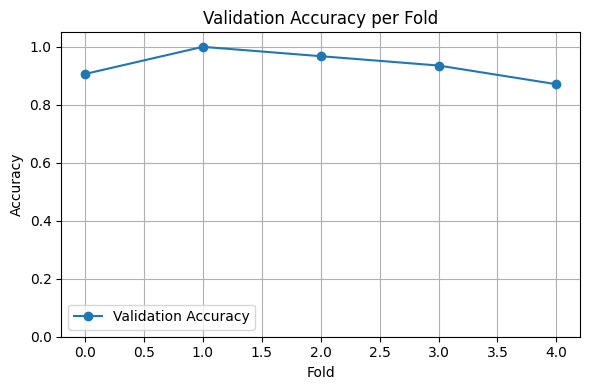

100%|██████████| 5/5 [4:04:26<00:00, 2933.39s/it]


✅ Nested CV Completed in 244.4 minutes
📊 Mean Accuracy: 0.9361 ± 0.0452
📝 Best parameters per fold:
  Fold 1: {'batch_size': 16, 'epochs': 15, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.0005, 'model__lstm_units': 128}
  Fold 2: {'batch_size': 32, 'epochs': 15, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.0005, 'model__lstm_units': 128}
  Fold 3: {'batch_size': 16, 'epochs': 15, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.0005, 'model__lstm_units': 128}
  Fold 4: {'batch_size': 32, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.0005, 'model__lstm_units': 128}
  Fold 5: {'batch_size': 32, 'epochs': 15, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__lstm_units': 64}


In [7]:
# Convert to numpy arrays
X = np.array(X_train)
y = np.array(y_train)

# Outer CV setup
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
validation_scores = []
best_params_per_fold = []

# Track total time
start_total = time.time()

# Nested CV loop with progress bar
for fold, (train_idx, val_idx) in enumerate(tqdm(outer_cv.split(X, y), total=outer_cv.get_n_splits()), start=1):
    fold_start = time.time()

    X_inner, X_outer = X[train_idx], X[val_idx]
    y_inner, y_outer = y[train_idx], y[val_idx]

    # Keras model wrapper
    model = KerasClassifier(
        model=create_bilstm_model,
        model__input_shape=(X.shape[1], X.shape[2]),
        epochs=30,
        batch_size=16,
        verbose=0,
        metrics=["accuracy"]
    )

    # Inner grid search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=1
    )
    grid_search.fit(X_inner, y_inner)

    # Evaluate on outer fold
    best_model = grid_search.best_estimator_
    val_score = best_model.score(X_outer, y_outer)

    # Track results
    validation_scores.append(val_score)
    best_params_per_fold.append(grid_search.best_params_)

    fold_duration = time.time() - fold_start
    print(f"\n🧪 Fold {fold} - Val Accuracy: {val_score:.4f} | Time: {fold_duration/60:.1f} min")
    print(f"🔧 Best Params: {grid_search.best_params_}")

    # Live plot
    clear_output(wait=True)
    plt.figure(figsize=(6, 4))
    plt.plot(validation_scores, marker="o", label="Validation Accuracy")
    plt.title("Validation Accuracy per Fold")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Final summary
total_duration = time.time() - start_total
mean_acc = np.mean(validation_scores)
std_acc = np.std(validation_scores)

print(f"\n✅ Nested CV Completed in {total_duration/60:.1f} minutes")
print(f"📊 Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print("📝 Best parameters per fold:")
for i, params in enumerate(best_params_per_fold, start=1):
    print(f"  Fold {i}: {params}")


# Train the final model with the best hyperparameters

In [ ]:
# Apparently this only outputs the best parameters from the last fold and not the best parameters overall (most common over all folds) 
# print(f"\n Best overall parameters: {grid_search.best_params_}")

final_params = {
    "model__lstm_units": 128,
    "model__dropout_rate": 0.2,
    "model__learning_rate": 0.0005,
    "epochs": 15,
    "batch_size": 32
}

# Rebuild the final model
final_model = create_bilstm_model(
    input_shape=(X.shape[1], X.shape[2]),
    lstm_units=final_params["model__lstm_units"],
    dropout_rate=final_params["model__dropout_rate"],
    learning_rate=final_params["model__learning_rate"]
)

# Train it
final_model.fit(
    X, y,
    epochs=final_params["epochs"],
    batch_size=final_params["batch_size"],
    verbose=1
)


final_model.save("final_bilstm_model.h5")
print("**** Final model saved to final_bilstm_model.h5 ****")



# Evaluation

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Get predictions and convert probabilities to binary labels
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int")

# Print classification report
print(classification_report(y_test, y_pred))

# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f" ROC-AUC Score: {roc_auc:.4f}")

NameError: name 'test_model' is not defined